In [1]:
import os, re, time
import pandas as pd
from tqdm.auto import tqdm
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go


CORPUS = "/Users/gmello/Documents/python_repos/mestrado/resultados_experimentos"
UA     = "/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea"


ALGORITMOS = ['b1',   'b3',   'b4',   'b5m',  'b5r',
              'c122', 'c141', 'c149', 'c154', 'c217', 
              'c238', 'c262', 'e7',   'e74',  'e81',  'e103',
              # pisos
              'nsga2', 'nsga3', 
              'moead', 'moead_media',
              'smsemoa'
             ]

OFFLINES  = {'b5m': 'off', 'b5r': 'off', 'e103': 'off', 'moead_media': 'off'}


PROBLEMAS = ["MMF1", "MMF4", "MMF11_L", "MMF16_20",
             "ZDT1", "ZDT3", "ZDT4", "ZDT6", 
             "DTLZ1", "DTLZ2", "DTLZ3", "DTLZ4", "DTLZ7",
             "WFG1", "WFG2", "WFG4", "WFG5", "WFG9", 
             "BBOB_F1", "BBOB_F5", "BBOB_F17", "BBOB_F22", "BBOB_F37", "BBOB_F49", "BBOB_F55",
             "RE21", "ESTOQUE40", "DDMOP7"]


SEEDS = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,42]


TABELAS = {'real': 'real',           # avaliacoes reais realizadas
           'surrogate': 'surrogate', # avaliacoes surrogate + sonda realizadas
           'populacao': 'pop',       # individuos na populacao por geracao
           'tempo': 'timing',        # tempo de execucao
           'final': 'final'}         # avaliacao veradeira de solucoes finais em algoritmos offline


METRICAS = {'HV': 'HV ↑', 'IGD': 'IGD ↓', 'Gamma': 'Gamma ↓', 'Delta': 'Delta ↓'}


## 1. Análise completude experimentos

Conclusões
* [0] 14 algoritmos + 5 pisos e 27 problemas bem completos! \o/
* [1] estoque40 vira sub experimento (bem incompleto)
* [2] c154(JES) não rolou  --- deixar no cap4 e explicar no 5 que nao deu
    * tem varios incompletos dele -> explicar teto 12h e talvez sub estudo mostrar parciais 


In [2]:
def ler_dataframe(algoritmo, problema, seed, tabela):
    try: return pd.read_parquet(f'{CORPUS}/{algoritmo}/{problema}/{seed}/exp_{OFFLINES.get(algoritmo, "main")}_{algoritmo}_{problema}_{seed}__{tabela}.parquet')
    except: return None
    
PROCESSAR = False

if PROCESSAR:
    linhas = []
    for algoritmo in tqdm(ALGORITMOS):
        for problema in PROBLEMAS:
            for seed in SEEDS:

                # leitura de dados
                dict_df = {k: ler_dataframe(algoritmo, problema, seed, tabela) for k, tabela in TABELAS.items()}
                info    = dict(algoritmo=algoritmo, problema=problema, seed=seed, orcamento=None, orcamento_gasto=None, geracoes_gasto=None, tempo_execucao=None)

                # determina orcamento do experimento + mede orcamento real gasto
                if dict_df['real'] is not None:
                    D = dict_df['real'].filter(regex=r'^x\d+$').shape[1]
                    info.update(orcamento = 31*D - 1)
                    info.update(orcamento_gasto = len(dict_df['real']))

                # mede populacoes reais geradas
                if dict_df['populacao'] is not None:
                    info['geracoes_gasto'] = dict_df['populacao'].geracao.max()

                # mede tempo total de execucao
                if dict_df['tempo'] is not None:
                    df_tempo = dict_df['tempo']
                    cols = ['tempo_geracao_s', 'tempo_pred_sonda_s', 'tempo_checkpoint_s'] if 'tempo_geracao_s' in df_tempo else ['tempo_fit_s', 'tempo_busca_s']
                    info['tempo_execucao'] = df_tempo.reindex(columns=cols).sum().sum() / 3600

                # registra dados medidos
                for k in TABELAS:
                    linhas.append({**info, 'output': k, 'existe': dict_df[k] is not None})

    # unifica resultados
    df = pd.DataFrame(linhas)

    # determina status do experimento
    df['geracoes_esperadas'] = df.groupby(['algoritmo', 'problema']).geracoes_gasto.transform('max')
    completo = (df.orcamento_gasto >= df.orcamento) | (df.algoritmo.isin(OFFLINES) & (df.geracoes_gasto == df.geracoes_esperadas))
    df['status'] = None
    tem = df.orcamento_gasto.notna()
    df.loc[tem, 'status'] = 'incompleto sem teto 12h'
    df.loc[tem & (df.tempo_execucao >= 11*3600), 'status'] = 'teto 12h'
    df.loc[completo, 'status'] = 'completo'
    df['status'] = df['status'].fillna('nulo')

    # Salva resultado
    df.to_parquet('df_status_experimentos.parquet')

else:
    df = pd.read_parquet('df_status_experimentos.parquet')

df

,algoritmo,problema,seed,orcamento,orcamento_gasto,geracoes_gasto,tempo_execucao,output,existe,geracoes_esperadas,status
0,b1,MMF1,0,61.0,61.0,42.0,0.007720,real,True,72.0,completo
1,b1,MMF1,0,61.0,61.0,42.0,0.007720,surrogate,True,72.0,completo
2,b1,MMF1,0,61.0,61.0,42.0,0.007720,populacao,True,72.0,completo
3,b1,MMF1,0,61.0,61.0,42.0,0.007720,tempo,True,72.0,completo
4,b1,MMF1,0,61.0,61.0,42.0,0.007720,final,False,72.0,completo
...,...,...,...,...,...,...,...,...,...,...,...
88195,smsemoa,DDMOP7,42,526.0,526.0,18.0,0.591159,real,True,18.0,completo
88196,smsemoa,DDMOP7,42,526.0,526.0,18.0,0.591159,surrogate,True,18.0,completo
88197,smsemoa,DDMOP7,42,526.0,526.0,18.0,0.591159,populacao,True,18.0,completo
88198,smsemoa,DDMOP7,42,526.0,526.0,18.0,0.591159,tempo,True,18.0,completo


In [3]:
print(f'{round(15047 / (21 * 28 * 30)*100)}% dos experimentos completos')
df[df.output == 'real']['status'].value_counts()

85% dos experimentos completos


status
completo                   15862
nulo                        1014
incompleto sem teto 12h      764
Name: count, dtype: int64

In [4]:
df[(df.output == 'real')&(df.status == 'incompleto sem teto 12h')].head()

,algoritmo,problema,seed,orcamento,orcamento_gasto,geracoes_gasto,tempo_execucao,output,existe,geracoes_esperadas,status
21575,c122,MMF16_20,25,619.0,564.0,345.0,4.685233,real,True,400.0,incompleto sem teto 12h
21635,c122,ZDT1,7,929.0,923.0,594.0,8.406286,real,True,600.0,incompleto sem teto 12h
21740,c122,ZDT1,28,929.0,913.0,584.0,11.918024,real,True,600.0,incompleto sem teto 12h
21745,c122,ZDT1,42,929.0,894.0,565.0,11.988909,real,True,600.0,incompleto sem teto 12h
21770,c122,ZDT3,4,929.0,892.0,563.0,11.959092,real,True,600.0,incompleto sem teto 12h


In [5]:
real = df[df.output == 'real']
paineis = {
    '(1) todos os completos': real[real.status == 'completo'],
    '(2) completos limpeza':  real[(real.status == 'completo') & (real.algoritmo != 'c154') & (real.problema != 'ESTOQUE40')],
    '(3) incompletos':        real[real.status == 'incompleto sem teto 12h'],
    '(4) nulos':              real[real.status == 'nulo'],
}

fig = make_subplots(rows=2, cols=2, subplot_titles=list(paineis))
for i, sub in enumerate(paineis.values()):
    p = sub.pivot_table(index='algoritmo', columns='problema', values='seed', aggfunc='count')
    fig.add_trace(go.Heatmap(z=p.values, x=p.columns, y=p.index, coloraxis='coloraxis'), row=i//2 + 1, col=i%2 + 1)
fig.update_yaxes(autorange='reversed')
fig.update_layout(width=1300, height=1000)
fig.show()

## 2. Métricas de qualidade

As 4 métricas são as do notebook 2 (`HV ↑`, `IGD ↓`, `Γ ↓`, `Δ ↓`), calculadas no espaço de
objetivos cru contra o PF verdadeiro de `problem.true_pareto_front()`. O front de cada execução
é o conjunto não dominado das avaliações **verdadeiras**: camada ① nos online, camada ⑦ nos
offline (onde o conjunto final é reavaliado na função verdadeira). 

### Catálogo de exibição (nomes, cores e opções de plot)

Nome de exibição por algoritmo (o capítulo não usa id interno em figura nem tabela), cor fixa
por algoritmo (o mesmo algoritmo tem a mesma cor em toda figura), e os limites de eixo e
`pair_vars` de cada problema, transcritos do notebook 1.

In [6]:
# ── Catálogo de exibição: nomes, cores e opções de plot por problema ──────────
# NOMES: o capítulo não usa id interno em figura nem tabela — só nome de exibição.
NOMES = {'b1': 'ParEGO', 'b3': 'K-RVEA', 'b4': 'CSEA', 'c122': 'θ-DEA-DP', 'c141': 'MMRAEA',
         'c149': 'LBN-MOBO', 'c154': 'JES', 'c217': 'PC-SAEA', 'c238': 'EIM', 'c262': 'qNEHVI',
         'e7': 'EDN-ARMOEA', 'e74': 'CLMEA', 'e81': 'qPOTS',
         'b5m': 'Prob-MOEA/D', 'b5r': 'Prob-RVEA', 'e103': 'IBEA-MS',
         'nsga2': 'NSGA-II', 'nsga3': 'NSGA-III', 'moead': 'MOEA/D', 'smsemoa': 'SMS-EMOA',
         'moead_media': 'MOEA/D-média'}

# CORES: cor fixa por algoritmo (o mesmo algoritmo tem a mesma cor em toda figura do capítulo).
# Os 5 pisos ficam em cinza, para separá-los dos assistidos à primeira vista.
CORES = {'b1': 'tab:blue', 'b3': 'tab:orange', 'b4': 'tab:green', 'c122': 'tab:red',
         'c141': 'tab:purple', 'c149': 'tab:brown', 'c154': 'tab:pink', 'c217': 'olive',
         'c238': 'tab:cyan', 'c262': 'gold', 'e7': 'darkviolet', 'e74': 'teal', 'e81': 'crimson',
         'b5m': 'royalblue', 'b5r': 'mediumseagreen', 'e103': 'darkorange',
         'nsga2': 'dimgray', 'nsga3': 'darkgray', 'moead': 'gray', 'smsemoa': 'silver',
         'moead_media': 'lightgray'}

# PROBLEM_PLOT_OPTS: limites de eixo e variáveis do grid pairwise, transcritos do notebook 1.
# RE21, ESTOQUE40 e DDMOP7 não estão no notebook 1 e caem no padrão abaixo.
_BBOB = dict(true_color='white', elev_offset=-27, azim_offset=225, roll_offset=0)
PLOT_OPTS_PADRAO = dict(pair_vars=[1, 2, 3])   # sem isto o ESTOQUE40 (D=40) tenta um grid 40×40

PROBLEM_PLOT_OPTS = {
    'MMF1': {}, 'MMF4': {}, 'MMF11_L': {}, 'MMF16_20': dict(pair_vars=[1, 2, 20]),
    'ZDT1': dict(pair_vars=[1, 2], true_color='white', elev_offset=-27, azim_offset=225, roll_offset=0),
    'ZDT3': dict(pair_vars=[1, 2]), 'ZDT4': dict(pair_vars=[1, 2]), 'ZDT6': dict(pair_vars=[1, 2]),
    'DTLZ1': dict(xlim=(0, 100), ylim=(0, 100), zlim=(0, 100), pair_vars=[1, 2, 3]),
    'DTLZ2': dict(xlim=(0, 2), ylim=(0, 2), zlim=(0, 2), pair_vars=[1, 2, 3]),
    'DTLZ3': dict(xlim=(0, 1000), ylim=(0, 1000), zlim=(0, 1000), pair_vars=[1, 2, 3]),
    'DTLZ4': dict(xlim=(0, 2), ylim=(0, 2), zlim=(0, 2), pair_vars=[1, 2, 3]),
    'DTLZ7': dict(zlim=(0, 20), pair_vars=[1, 2, 3]),
    'WFG1': dict(pair_vars=[1, 2, 3]), 'WFG2': dict(pair_vars=[1, 2, 3]),
    'WFG4': dict(pair_vars=[1, 2, 3]), 'WFG5': dict(pair_vars=[1, 2, 3]),
    'WFG9': dict(pair_vars=[1, 2, 3]),
    'BBOB_F1':  dict(xlim=(0, 210),       ylim=(0, 210),  pair_vars=[1, 2, 3, 4], **_BBOB),
    'BBOB_F5':  dict(xlim=(0, 220),       ylim=(0, 3200), pair_vars=[1, 2, 3, 4], **_BBOB),
    'BBOB_F17': dict(xlim=(0, 5_000_000), ylim=(0, 200),  pair_vars=[1, 2, 3, 4], **_BBOB),
    'BBOB_F22': dict(xlim=(0, 500_000),   ylim=(0, 2000), pair_vars=[1, 2, 3, 4], **_BBOB),
    'BBOB_F37': dict(xlim=(0, 3500),      ylim=(0, 7000), pair_vars=[1, 2, 4, 5], **_BBOB),
    'BBOB_F49': dict(xlim=(0, 5000),                      pair_vars=[1, 3, 7, 9], **_BBOB),
    'BBOB_F55': dict(                                     pair_vars=[1, 3, 5, 6], **_BBOB),
}

# Quais chaves cada função de visualização aceita (xlim/ylim/zlim só no espaço de objetivos;
# pair_vars só no espaço de decisões) — passar a chave errada levanta TypeError.
OPTS_OBJ = ('xlim', 'ylim', 'zlim', 'true_color', 'emp_color', 'elev_offset', 'azim_offset', 'roll_offset')
OPTS_DEC = ('pair_vars', 'true_color', 'emp_color', 'elev_offset', 'azim_offset', 'roll_offset')

def opts_de(problema, aceitas, extra):
    o = {**PLOT_OPTS_PADRAO, **PROBLEM_PLOT_OPTS.get(problema, {})}
    return {**{k: v for k, v in o.items() if k in aceitas}, **extra}

In [7]:
import sys, numpy as np
from scipy.spatial.distance import cdist
from pymoo.indicators.hv import HV
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

sys.path.insert(0, UA)
from src.experiment import _instantiate_problem
from src.visualization import display_pareto_fronts_catalog, display_decision_space

ENDPOINT = {a: 'final' for a in OFFLINES}   # offline: camada ⑦ (conjunto final avaliado de verdade); online: camada ①
_FRONTES = {}

def front_teorico(problema, n=500):
    """PF verdadeiro: analítico na maioria, empírico cacheado nos BBOB/RE21/ESTOQUE40 (DDMOP7 não tem)."""
    if problema not in _FRONTES:
        _FRONTES[problema] = _instantiate_problem(problema).true_pareto_front(n)[1]
    return _FRONTES[problema]

def front_encontrado(algoritmo, problema, seed, colunas='f'):
    """Front não dominado das avaliações verdadeiras.
    colunas='f' devolve os objetivos; colunas='x' devolve as variáveis de decisão das MESMAS soluções."""
    d = ler_dataframe(algoritmo, problema, seed, ENDPOINT.get(algoritmo, 'real'))
    if d is None: return None
    F = d.filter(regex=r'^f\d+$').to_numpy(float)
    nd = NonDominatedSorting().do(F, only_non_dominated_front=True)
    return (F if colunas == 'f' else d.filter(regex=r'^x\d+$').to_numpy(float))[nd]

def metricas(F, F_true):
    """HV ↑ · IGD ↓ · Gamma ↓ · Delta ↓ — mesmas definições do notebook 2."""
    d_pa, d_ap = cdist(F_true, F), cdist(F, F_true)
    d = np.linalg.norm(np.diff(F[np.lexsort(F[:, ::-1].T)], axis=0), axis=1)
    d_f, d_l = d_pa[np.argmin(F_true[:, 0])].min(), d_pa[np.argmin(F_true[:, -1])].min()
    return {'HV':    float(HV(ref_point=F_true.max(0) * 1.1 + 0.01)(F)),
            'IGD':   float(d_pa.min(1).mean()),
            'Gamma': float(d_ap.min(1).mean()),
            'Delta': float((d_f + d_l + np.abs(d - d.mean()).sum()) / (d_f + d_l + len(d) * d.mean())),
            'n_solucoes': len(F)}


def top_n(df_metricas, problema, n=5, metrica='HV', seed=None):
    """Os n melhores algoritmos no problema pela mediana da métrica sobre as sementes (ou por uma semente só)."""
    s = df_metricas[df_metricas.problema == problema]
    s = s if seed is None else s[s.seed == seed]
    s = s.groupby('algoritmo')[metrica].median().dropna()
    return list(s.sort_values(ascending=metrica != 'HV').index[:n])


def landscape(problema, prob):
    """Amostra Sobol do notebook 1 (X, F) usada como fundo; arrays vazios se o parquet não existir."""
    nome = problema.replace('BBOB_F', 'BBOB')                      # o notebook 1 gravou os BBOB sem o 'F'
    arq = f'{UA}/data/dataframes/{nome}/df_{nome}_landscape_sobol.parquet'
    if not os.path.exists(arq):
        return np.empty((0, prob.n_var)), np.empty((0, prob.n_obj))
    d = pd.read_parquet(arq)
    return (d[[f'x_{i+1}' for i in range(prob.n_var)]].to_numpy(),
            d[[f'f{j+1}' for j in range(prob.n_obj)]].to_numpy())

def _conjuntos(problema, seed, algoritmos, colunas):
    """{algoritmo: pontos} descartando quem não tem execução; devolve também nomes e cores de exibição."""
    c = {a: front_encontrado(a, problema, seed, colunas) for a in algoritmos}
    c = {a: p for a, p in c.items() if p is not None and len(p)}
    return list(c.values()), [NOMES.get(a, a) for a in c], [CORES.get(a) for a in c]


def visualizar_objetivos(problema, seed, algoritmos, com_landscape=True, **kwargs):
    """Espaço de objetivos: PF teórico + o front de cada algoritmo, sobre a landscape do notebook 1."""
    prob = _instantiate_problem(problema)
    _, F_bg = landscape(problema, prob) if com_landscape else (None, np.empty((0, prob.n_obj)))
    pontos, nomes, cores = _conjuntos(problema, seed, algoritmos, 'f')
    display_pareto_fronts_catalog(prob, F_bg, pareto_fronts_list=pontos, front_names=nomes,
                                  front_colors=cores, title=f'{problema} · seed {seed}',
                                  **opts_de(problema, OPTS_OBJ, kwargs))


def visualizar_decisoes(problema, seed, algoritmos, pca=False, com_landscape=True, **kwargs):
    """Espaço de decisões: PS teórico + o PS de cada algoritmo (as mesmas soluções do front).

    D ≤ 2 → heatmap; D = 3 → dispersão 3D; D > 3 → grid pairwise das `pair_vars`.
    `pca=True` acrescenta as grades de PCA por objetivo (2D e 3D) — só existem para D > 3."""
    prob = _instantiate_problem(problema)
    X_bg, F_bg = landscape(problema, prob) if com_landscape else (np.empty((0, prob.n_var)), np.empty((0, prob.n_obj)))
    try:
        X_true = np.atleast_2d(prob.true_pareto_front()[0])
    except NotImplementedError:                                    # DDMOP7 (D102.4): sem front de referência
        X_true = np.empty((0, prob.n_var))
    pontos, nomes, cores = _conjuntos(problema, seed, algoritmos, 'x')
    display_decision_space(prob, X_bg, F_bg, X_true, X_emp_list=pontos, emp_names=nomes,
                           emp_colors=cores, title=f'{problema} · seed {seed}',
                           show_2d_pca=pca, show_3d_pca=pca,
                           **opts_de(problema, OPTS_DEC, kwargs))

In [8]:
if PROCESSAR:
    linhas = []
    chaves = df[(df.output == 'real') & df.existe][['algoritmo', 'problema', 'seed']]
    for algoritmo, problema, seed in tqdm(list(chaves.itertuples(index=False, name=None))):
        linha = {'algoritmo': algoritmo, 'problema': problema, 'seed': seed, 'erro': None}
        try:
            linha.update(metricas(front_encontrado(algoritmo, problema, seed), front_teorico(problema)))
        except Exception as e:
            linha['erro'] = f'{type(e).__name__}: {e}'
        linhas.append(linha)

    df_metricas = pd.DataFrame(linhas)
    df_metricas.to_parquet('df_metricas.parquet')

else:
    df_metricas = pd.read_parquet('df_metricas.parquet')

df_metricas

,algoritmo,problema,seed,erro,HV,IGD,Gamma,Delta,n_solucoes
0,b1,MMF1,0,None,0.772412,0.054783,0.022816,0.685801,18.0
1,b1,MMF1,1,None,0.752547,0.067947,0.020964,0.614335,11.0
2,b1,MMF1,2,None,0.661711,0.129521,0.038038,0.846809,11.0
3,b1,MMF1,3,None,0.767952,0.064221,0.043459,0.851976,19.0
4,b1,MMF1,4,None,0.762555,0.074032,0.034253,0.807885,14.0
...,...,...,...,...,...,...,...,...,...
16621,smsemoa,DDMOP7,25,NotImplementedError: D102.4: DDMOP7 não tem fr...,NaN,NaN,NaN,NaN,NaN
16622,smsemoa,DDMOP7,26,NotImplementedError: D102.4: DDMOP7 não tem fr...,NaN,NaN,NaN,NaN,NaN
16623,smsemoa,DDMOP7,27,NotImplementedError: D102.4: DDMOP7 não tem fr...,NaN,NaN,NaN,NaN,NaN
16624,smsemoa,DDMOP7,28,NotImplementedError: D102.4: DDMOP7 não tem fr...,NaN,NaN,NaN,NaN,NaN


In [9]:
dfm = df_metricas[df_metricas['erro'].isnull()]
dfm = dfm.groupby(['algoritmo','problema'])[['HV','IGD','Gamma','Delta']].median().reset_index()

dfm

,algoritmo,problema,HV,IGD,Gamma,Delta
0,b1,BBOB_F1,6.625600e+03,3.131020e+00,2.232172,0.648808
1,b1,BBOB_F17,6.748482e+09,2.514683e+06,466722.677055,1.276619
2,b1,BBOB_F22,1.029350e+08,2.801880e+03,2889.475048,0.800908
3,b1,BBOB_F37,3.340020e+05,1.411566e+02,109.871274,1.030130
4,b1,BBOB_F49,6.616151e+04,9.728355e+01,47.228898,0.878695
...,...,...,...,...,...,...
553,smsemoa,WFG9,2.203989e+00,2.450415e-01,0.222213,0.756628
554,smsemoa,ZDT1,1.263122e-01,6.466908e-01,0.675729,0.871159
555,smsemoa,ZDT3,2.786172e-01,4.630809e-01,0.591417,0.842279
556,smsemoa,ZDT4,0.000000e+00,3.543218e+01,42.946067,0.923127


### Heatmap méticas nao normalizadas

In [10]:
#fig = make_subplots(rows=2, cols=2, subplot_titles=list(METRICAS.values()))
#for i, (m, titulo) in enumerate(METRICAS.items()):
#    p = dfm.pivot_table(index='algoritmo', columns='problema', values=m)
#    eixo = 'coloraxis' + ('' if i == 0 else str(i + 1))
#    fig.add_trace(go.Heatmap(z=p.values, x=p.columns, y=p.index, coloraxis=eixo), row=i//2 + 1, col=i%2 + 1)
#    fig.update_layout(**{eixo: dict(colorscale='Viridis' if m == 'HV' else 'Viridis_r',
#                                    colorbar=dict(title=titulo, len=0.42, thickness=12,
#                                                  x=0.46 + 0.58*(i % 2), y=0.79 - 0.58*(i//2)))})
#fig.update_yaxes(autorange='reversed')
#fig.update_layout(width=1300, height=1000)
#fig.show()

### Heatmap méticas normalizadas

In [11]:
d = dfm.copy()
for m in METRICAS:
    g = d.groupby('problema')[m]
    d[m] = (d[m] - g.transform('min')) / (g.transform('max') - g.transform('min'))
    if m != 'HV': d[m] = 1 - d[m]

fig = make_subplots(rows=2, cols=2, subplot_titles=[f'{t} (1 = melhor do problema)' for t in METRICAS.values()])
for i, m in enumerate(METRICAS):
    p = d.pivot_table(index='algoritmo', columns='problema', values=m)
    fig.add_trace(go.Heatmap(z=p.values, x=p.columns, y=p.index, coloraxis='coloraxis'), row=i//2 + 1, col=i%2 + 1)
fig.update_yaxes(autorange='reversed')
fig.update_layout(width=1300, height=1000, coloraxis=dict(colorscale='Viridis'))
fig.show()

## 3. Visualização dos fronts

A visualização reusa
`display_pareto_fronts_catalog` de `src/visualization.py`, a mesma dos notebooks 1 e 2.

In [26]:
ALGORITMO = 'c262'
PROBLEM   = "WFG2"
TOP_N     = 5
METRICA   = 'HV'
SEED      = 0

In [27]:
melhores = top_n(df_metricas, PROBLEM, TOP_N, METRICA)
print(f'top {TOP_N} em {METRICA} no {PROBLEM}: {melhores}')
metricas(front_encontrado(ALGORITMO, PROBLEM, SEED), front_teorico(PROBLEM))

top 5 em HV no WFG2: ['c262', 'b3', 'smsemoa', 'nsga2', 'nsga3']


{'HV': 5.512241270068795,
 'IGD': 0.20762183682769936,
 'Gamma': 0.09614561515534624,
 'Delta': 0.7866583975237281,
 'n_solucoes': 15}

/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/src/visualization.py:219: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/src/visualization.py:219: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/gmello/Documents/python_venvs/mestrado_experimentos_dissertacao/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gmello/Documents/python_venvs/mestrado_experimentos_dissertacao/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


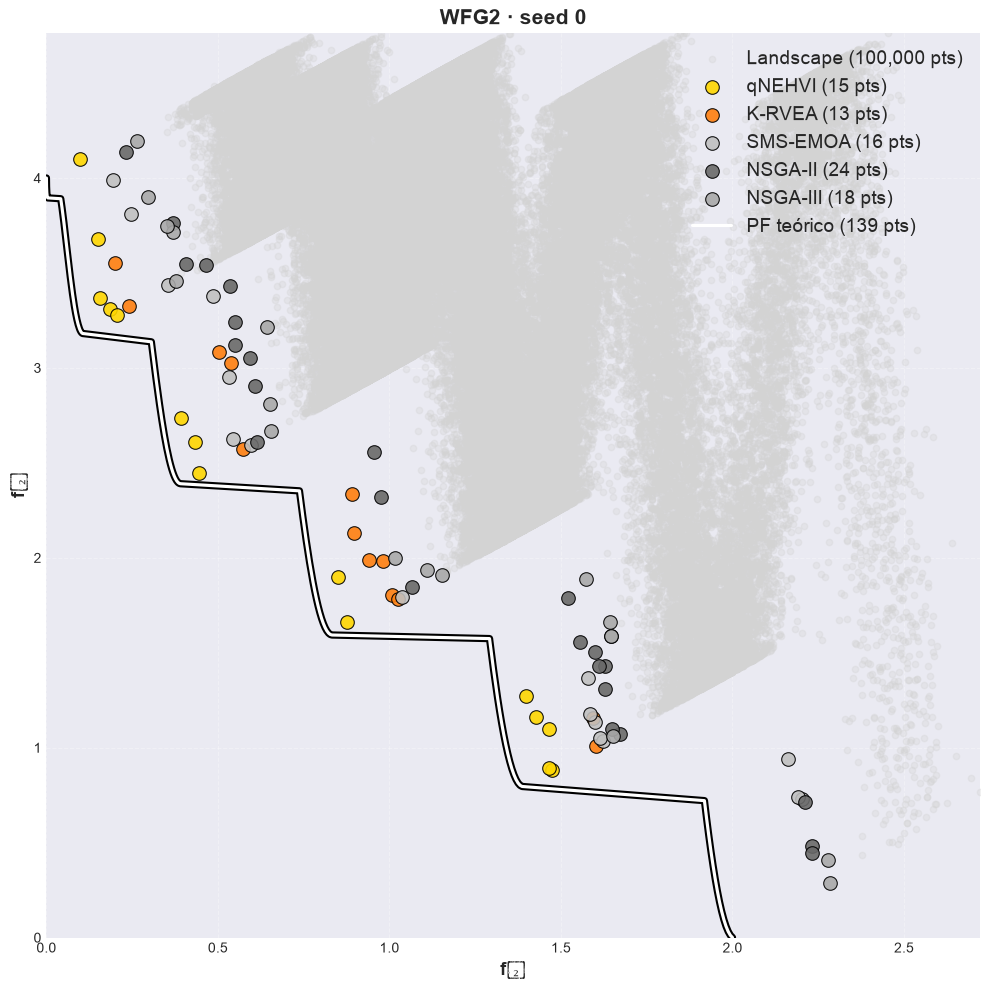

In [28]:
visualizar_objetivos(PROBLEM, SEED, melhores)

### Espaço de decisões

`visualizar_decisoes` mostra o conjunto de Pareto: o PS teórico mais as variáveis de decisão das
mesmas soluções do front de cada algoritmo. Com D ≤ 2 é um heatmap da landscape, com D > 3 é o
grid pairwise das `pair_vars` do problema. `pca=True` acrescenta as grades de PCA por objetivo
(2D e 3D) do notebook 1 — elas só existem para D > 3 e ficam desligadas por padrão.

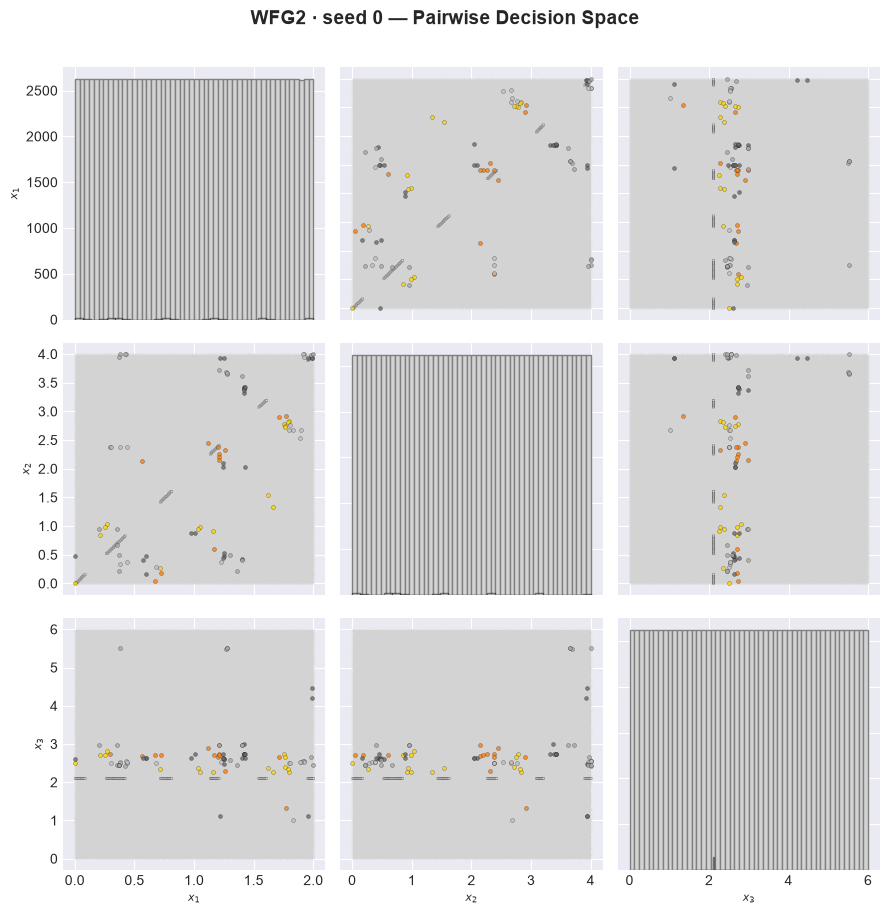

In [29]:
visualizar_decisoes(PROBLEM, SEED, melhores)

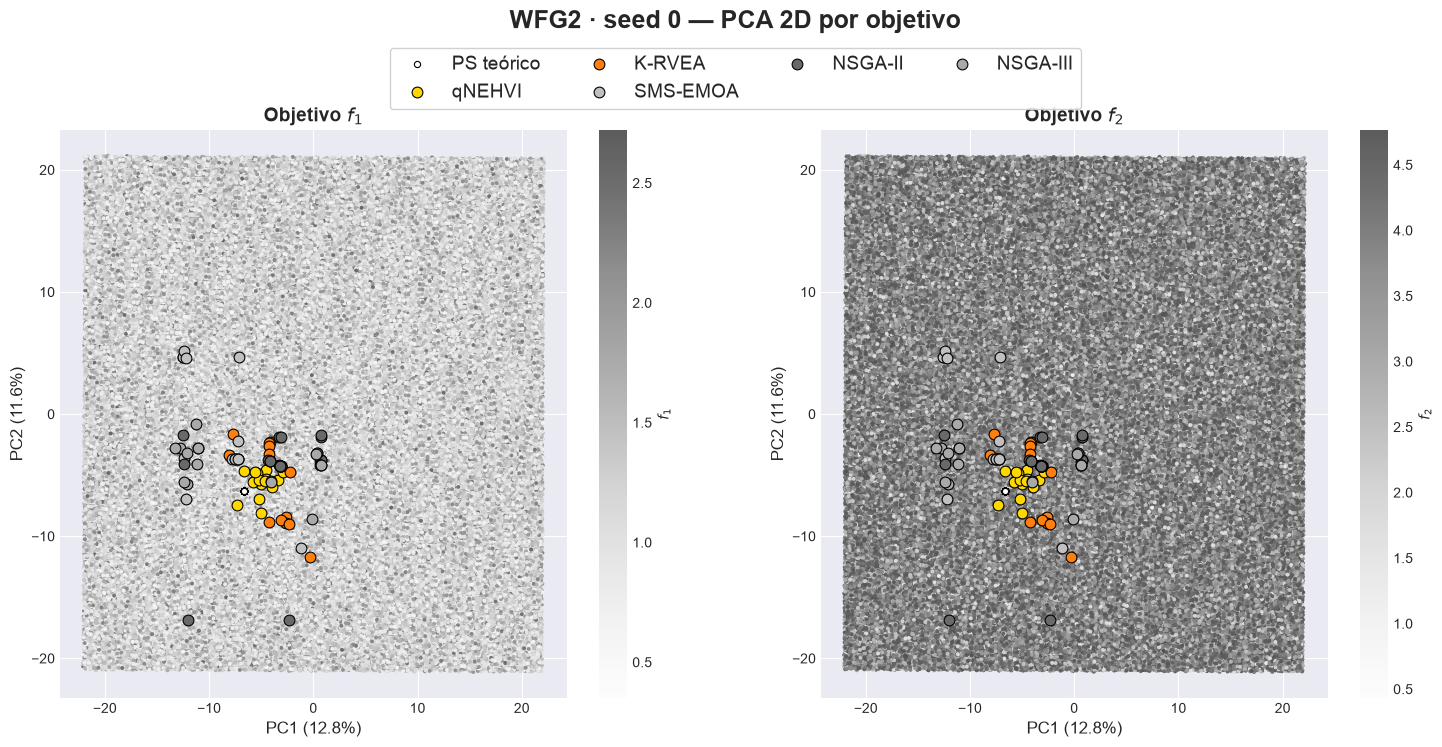

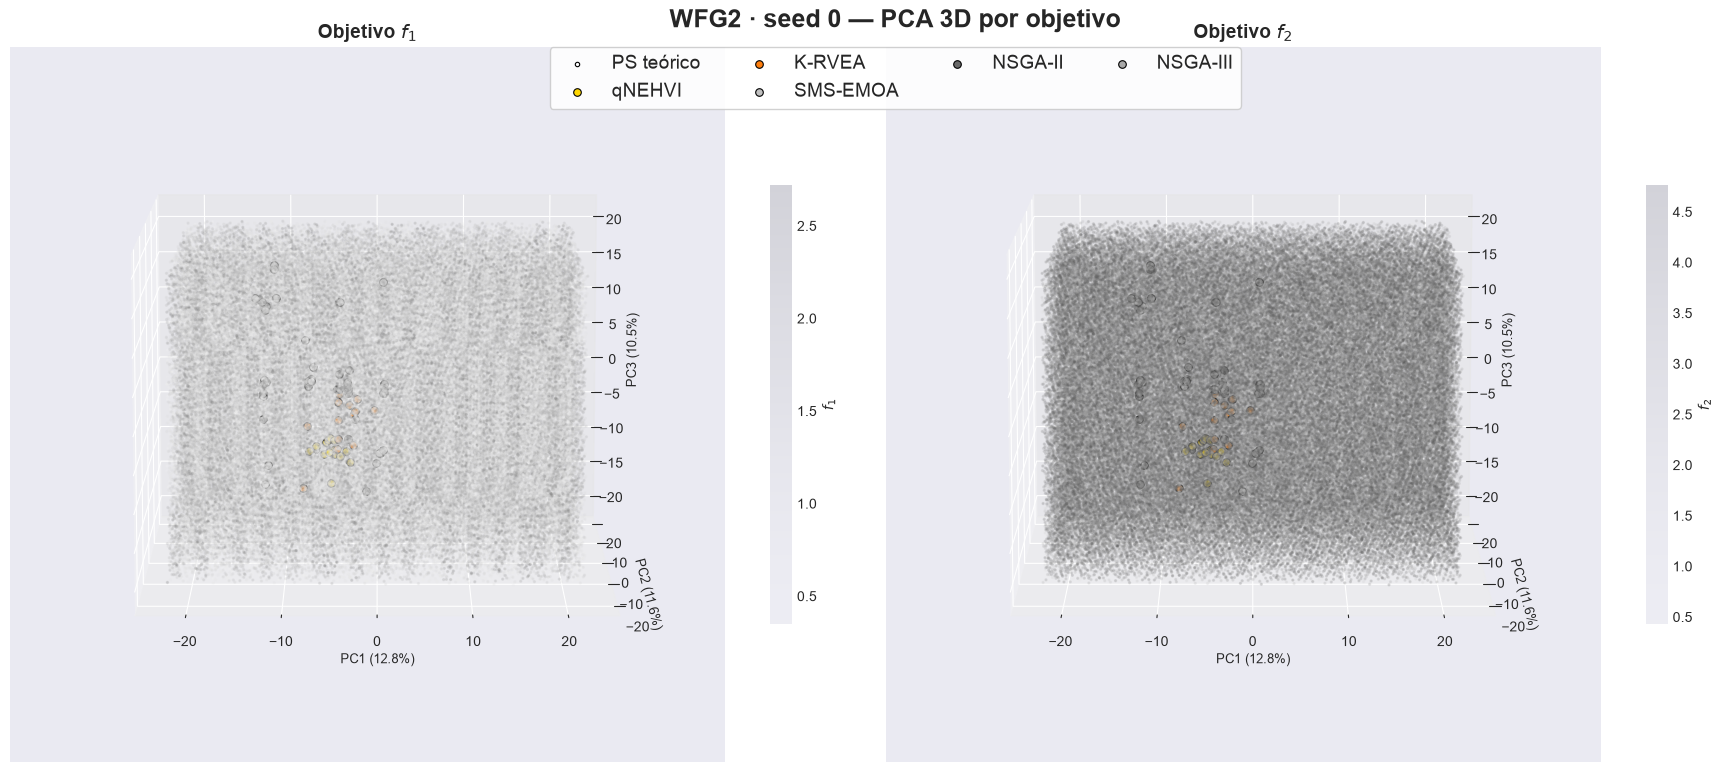

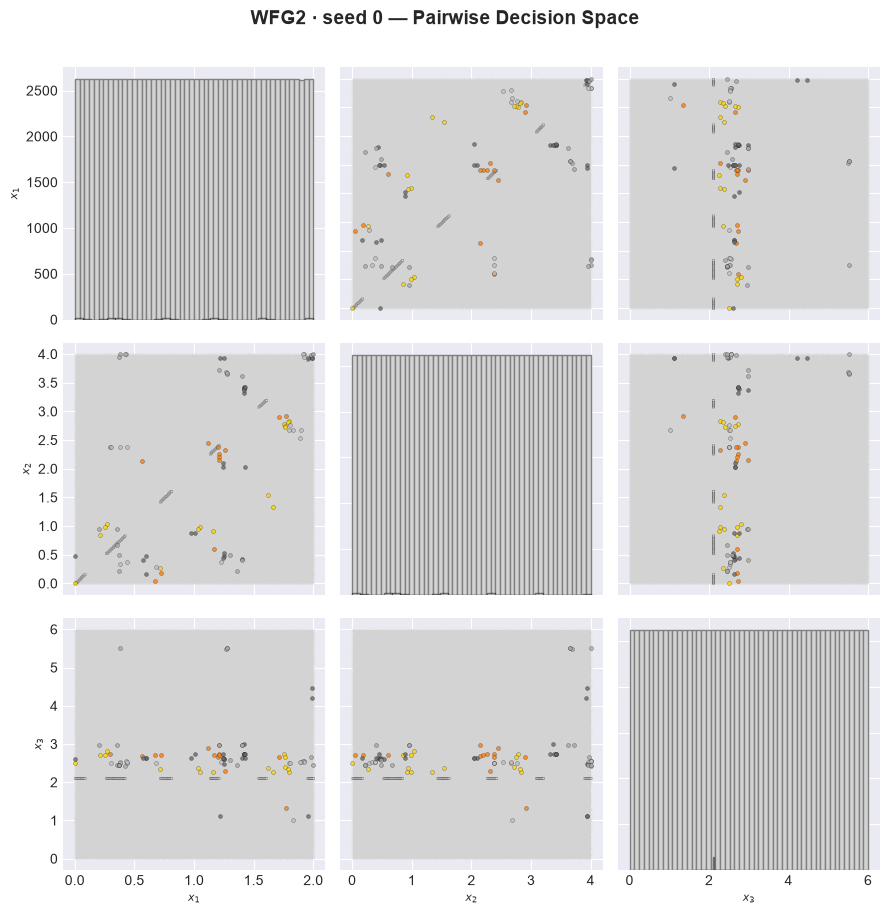

In [30]:
# as grades de PCA por objetivo (só valem para D > 3)
visualizar_decisoes(PROBLEM, SEED, melhores, pca=True)